# DS-5: Linear & Logistic Regression

## Objective
Build, evaluate, scale, and tune Linear Regression and Logistic Regression
models using scikit-learn.


In [2]:
import sys

print("Python version:", sys.version)

Python version: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]


In [4]:
import sklearn

print("Scikit-learn version:", sklearn.__version__)

Scikit-learn version: 1.9.1


In [1]:
import sklearn

In [2]:
from sklearn.datasets import load_diabetes

# Load dataset
diabetes = load_diabetes(as_frame=True)

# Convert to DataFrame
df = diabetes.frame

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 442
Columns: 11


In [10]:
# Separate features and target

X = df.drop("target", axis=1)
y = df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (442, 10)
Target shape: (442,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (353, 10)
Testing data: (89, 10)


## 2. Baseline Linear Regression Model

A Linear Regression model is trained to predict a continuous target variable from multiple input features.

In [12]:
from sklearn.linear_model import LinearRegression

# Create model
linear_model = LinearRegression()

# Train model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [13]:
# Predict on unseen test data

y_pred = linear_model.predict(X_test)

print("First 10 actual values:")
print(y_test.head(10).values)

print("\nFirst 10 predicted values:")
print(y_pred[:10])

First 10 actual values:
[219.  70. 202. 230. 111.  84. 242. 272.  94.  96.]

First 10 predicted values:
[139.5475584  179.51720835 134.03875572 291.41702925 123.78965872
  92.1723465  258.23238899 181.33732057  90.22411311 108.63375858]


In [16]:
import numpy as np

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Calculate predictions again to make sure y_pred exists
y_pred = linear_model.predict(X_test)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance")
print("--------------------------------")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R²  : {r2:.4f}")

Linear Regression Performance
--------------------------------
RMSE: 53.8534
MAE : 42.7941
R²  : 0.4526


## 3. Linear Regression Coefficient Interpretation

The coefficients indicate how each feature is associated with the predicted target while keeping other features constant.

In [18]:
import pandas as pd

# Get coefficients from the trained Linear Regression model
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

# Sort by coefficient
coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

print("Linear Regression Coefficients:")
print(coefficients)

Linear Regression Coefficients:
  Feature  Coefficient
8      s5   736.198859
2     bmi   542.428759
5      s2   518.062277
3      bp   347.703844
7      s4   275.317902
6      s3   163.419983
9      s6    48.670657
0     age    37.904021
1     sex  -241.964362
4      s1  -931.488846


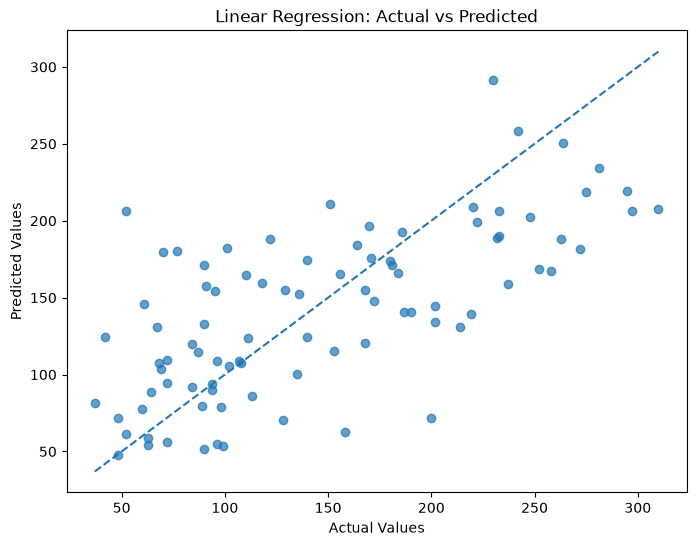

In [22]:
import matplotlib.pyplot as plt

# Make sure predictions exist
y_pred = linear_model.predict(X_test)

# Actual vs Predicted plot
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

# Perfect prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

In [24]:
# Create a clean results table

linear_results_df = pd.DataFrame([{
    "Model": "Linear Regression",
    "RMSE": rmse,
    "MAE": mae,
    "R2": r2
}])

linear_results_df

,Model,RMSE,MAE,R2
0,Linear Regression,53.853446,42.794095,0.452603


In [25]:
print("LINEAR REGRESSION BASELINE")
print("==========================")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

LINEAR REGRESSION BASELINE
RMSE : 53.8534
MAE  : 42.7941
R²   : 0.4526


# 5. Logistic Regression

The objective is to classify tumors as malignant or benign using the Breast Cancer Wisconsin dataset.

In [26]:
from sklearn.datasets import load_breast_cancer

# Load dataset
cancer = load_breast_cancer(as_frame=True)

# Convert to DataFrame
cancer_df = cancer.frame

print("Dataset loaded successfully!")
print("Rows:", cancer_df.shape[0])
print("Columns:", cancer_df.shape[1])

Dataset loaded successfully!
Rows: 569
Columns: 31


## 5.1 Dataset Inspection

Before training the Logistic Regression model, we inspect the dataset structure,
missing values, and class distribution.

In [27]:
print("Dataset Shape:", cancer_df.shape)

print("\nMissing Values:")
print(cancer_df.isnull().sum().sum())

print("\nTarget Distribution:")
print(cancer_df["target"].value_counts())

Dataset Shape: (569, 31)

Missing Values:
0

Target Distribution:
target
1    357
0    212
Name: count, dtype: int64


## 5.2 Feature and Target Separation

The target variable is `target`, while the remaining 30 columns are used as input features.

In [34]:
# Reset Logistic Regression features and target

X_log = cancer_df.drop("target", axis=1)
y_log = cancer_df["target"]

print("Features shape:", X_log.shape)
print("Target shape:", y_log.shape)

Features shape: (569, 30)
Target shape: (569,)


## 5.3 Train/Test Split

The dataset is divided into training and testing sets. Stratification is used
to preserve the class distribution in both sets.

In [35]:
from sklearn.model_selection import train_test_split

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log,
    y_log,
    test_size=0.20,
    random_state=42,
    stratify=y_log
)

print("Training samples:", X_train_log.shape[0])
print("Testing samples:", X_test_log.shape[0])

Training samples: 455
Testing samples: 114


## 5.4 Feature Scaling

StandardScaler is used to standardize the input features so that they have
approximately zero mean and unit variance.

In [36]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train_log)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test_log)

print("Training data scaled:", X_train_scaled.shape)
print("Testing data scaled:", X_test_scaled.shape)

Training data scaled: (455, 30)
Testing data scaled: (114, 30)


## 5.5 Logistic Regression Model

Logistic Regression is trained to classify observations into two classes:
malignant and benign.

In [37]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train model
logistic_model.fit(X_train_scaled, y_train_log)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


## 5.6 Model Prediction

The trained model is used to predict the classes of the unseen test data.

In [38]:
# Predict class labels
y_pred_log = logistic_model.predict(X_test_scaled)

print("First 20 actual values:")
print(y_test_log.iloc[:20].values)

print("\nFirst 20 predicted values:")
print(y_pred_log[:20])

First 20 actual values:
[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1]

First 20 predicted values:
[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1]


## 5.7 Classification Performance Evaluation

The Logistic Regression model is evaluated using Accuracy, Precision, Recall,
and F1-score.

In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Calculate metrics
accuracy = accuracy_score(y_test_log, y_pred_log)
precision = precision_score(y_test_log, y_pred_log)
recall = recall_score(y_test_log, y_pred_log)
f1 = f1_score(y_test_log, y_pred_log)

print("LOGISTIC REGRESSION PERFORMANCE")
print("================================")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

LOGISTIC REGRESSION PERFORMANCE
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1-Score : 0.9861


## 5.8 Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions
for each class.

In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_log, y_pred_log)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[41  1]
 [ 1 71]]


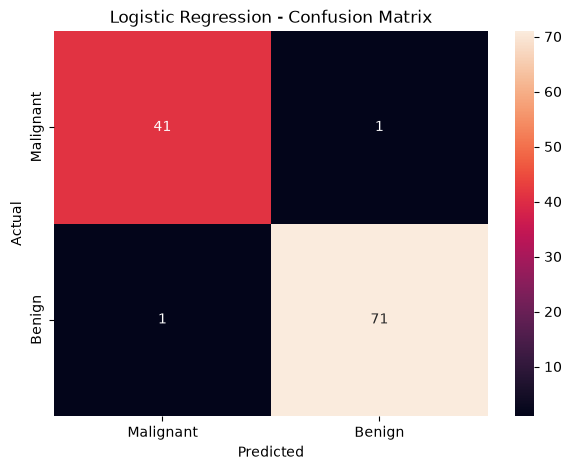

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test_log, y_pred_log)

# Plot confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

In [45]:
from sklearn.metrics import classification_report

print("LOGISTIC REGRESSION - CLASSIFICATION REPORT")
print("============================================")
print(classification_report(
    y_test_log,
    y_pred_log,
    target_names=["Malignant", "Benign"]
))

LOGISTIC REGRESSION - CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [46]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train_scaled, y_train_log)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'C': 0.1}
Best Cross-Validation Accuracy: 0.9802197802197803


In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

best_logistic_model = grid_search.best_estimator_

y_pred_tuned = best_logistic_model.predict(X_test_scaled)

tuned_accuracy = accuracy_score(y_test_log, y_pred_tuned)
tuned_precision = precision_score(y_test_log, y_pred_tuned)
tuned_recall = recall_score(y_test_log, y_pred_tuned)
tuned_f1 = f1_score(y_test_log, y_pred_tuned)

print("TUNED LOGISTIC REGRESSION PERFORMANCE")
print("======================================")
print(f"Accuracy : {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall   : {tuned_recall:.4f}")
print(f"F1-Score : {tuned_f1:.4f}")

TUNED LOGISTIC REGRESSION PERFORMANCE
Accuracy : 0.9737
Precision: 0.9726
Recall   : 0.9861
F1-Score : 0.9793


In [48]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Baseline": [accuracy, precision, recall, f1],
    "Tuned": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1
    ]
})

print("BASELINE vs TUNED LOGISTIC REGRESSION")
print("====================================")
print(comparison)

comparison

BASELINE vs TUNED LOGISTIC REGRESSION
      Metric  Baseline     Tuned
0   Accuracy  0.982456  0.973684
1  Precision  0.986111  0.972603
2     Recall  0.986111  0.986111
3   F1-Score  0.986111  0.979310


,Metric,Baseline,Tuned
0,Accuracy,0.982456,0.973684
1,Precision,0.986111,0.972603
2,Recall,0.986111,0.986111
3,F1-Score,0.986111,0.979310


## 6. Model Interpretation

The Logistic Regression model achieved high classification performance on the
Breast Cancer Wisconsin dataset.

The baseline model achieved an accuracy of 98.25%, precision of 98.61%,
recall of 98.61%, and F1-score of 98.61%.

GridSearchCV selected C = 0.1 as the best hyperparameter based on 5-fold
cross-validation, with a cross-validation accuracy of approximately 98.02%.

However, on the held-out test set, the tuned model achieved an accuracy of
97.37%, precision of 97.26%, recall of 98.61%, and F1-score of 97.93%.

Therefore, hyperparameter tuning did not improve the performance on this
particular test split. The results demonstrate the importance of evaluating
a tuned model on unseen test data rather than relying only on cross-validation
performance.

In [49]:
import pandas as pd

logistic_coefficients = pd.DataFrame({
    "Feature": X_log.columns,
    "Coefficient": best_logistic_model.coef_[0]
})

logistic_coefficients["Absolute_Coefficient"] = (
    logistic_coefficients["Coefficient"].abs()
)

logistic_coefficients = logistic_coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("TOP LOGISTIC REGRESSION FEATURES")
print("================================")
print(logistic_coefficients.head(10))

TOP LOGISTIC REGRESSION FEATURES
                 Feature  Coefficient  Absolute_Coefficient
21         worst texture    -0.563530              0.563530
20          worst radius    -0.509038              0.509038
27  worst concave points    -0.507791              0.507791
22       worst perimeter    -0.465531              0.465531
23            worst area    -0.460311              0.460311
1           mean texture    -0.439772              0.439772
10          radius error    -0.439074              0.439074
28        worst symmetry    -0.412812              0.412812
7    mean concave points    -0.403913              0.403913
0            mean radius    -0.397267              0.397267


## 7. Logistic Regression Summary

The Logistic Regression model was trained after standardizing the input
features. The baseline model achieved 98.25% accuracy on the test set.

GridSearchCV identified C = 0.1 as the best hyperparameter with a 5-fold
cross-validation accuracy of approximately 98.02%.

On the held-out test set, the tuned model achieved 97.37% accuracy,
97.26% precision, 98.61% recall, and 97.93% F1-score.

The coefficient analysis showed that features such as worst texture,
worst radius, worst concave points, worst perimeter, and worst area had
relatively large absolute coefficients in the fitted model.

Overall, the experiment demonstrates the complete Logistic Regression
workflow: data preparation, train-test splitting, feature scaling,
model training, evaluation, confusion matrix analysis, hyperparameter
tuning, and coefficient interpretation.

In [50]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(
    LinearRegression(),
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_squared_error"
)

cv_rmse = np.sqrt(-cv_scores)

print("LINEAR REGRESSION - 5-FOLD CROSS VALIDATION")
print("============================================")
print("RMSE for each fold:")
print(cv_rmse)
print(f"\nMean CV RMSE: {cv_rmse.mean():.4f}")
print(f"Standard Deviation: {cv_rmse.std():.4f}")

LINEAR REGRESSION - 5-FOLD CROSS VALIDATION
RMSE for each fold:
[52.53034465 58.93522481 52.08727478 56.50041896 59.80716652]

Mean CV RMSE: 55.9721
Standard Deviation: 3.1845


In [51]:
linear_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

linear_coefficients["Absolute_Coefficient"] = (
    linear_coefficients["Coefficient"].abs()
)

linear_coefficients = linear_coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("TOP LINEAR REGRESSION FEATURES")
print("=============================")
print(linear_coefficients.head(10))

TOP LINEAR REGRESSION FEATURES
  Feature  Coefficient  Absolute_Coefficient
4      s1  -931.488846            931.488846
8      s5   736.198859            736.198859
2     bmi   542.428759            542.428759
5      s2   518.062277            518.062277
3      bp   347.703844            347.703844
7      s4   275.317902            275.317902
1     sex  -241.964362            241.964362
6      s3   163.419983            163.419983
9      s6    48.670657             48.670657
0     age    37.904021             37.904021


## 8. Linear Regression Summary

Linear Regression was applied to the Diabetes dataset using an 80:20
train-test split.

The model was evaluated using RMSE, MAE, and R² metrics. Five-fold
cross-validation was also performed, resulting in a mean CV RMSE of
55.9721 with a standard deviation of 3.1845.

Coefficient analysis showed that s1, s5, bmi, s2, and bp had relatively
large absolute coefficients in the fitted model.

The actual-versus-predicted visualization was used to assess how closely
the predicted values followed the actual target values.

Overall, the experiment demonstrates the complete Linear Regression
workflow including data preparation, model training, prediction,
evaluation, cross-validation, visualization, and coefficient analysis.

In [52]:
final_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Logistic Regression (Baseline)",
        "Logistic Regression (Tuned)"
    ],
    "RMSE": [
        rmse,
        None,
        None
    ],
    "MAE": [
        mae,
        None,
        None
    ],
    "R2": [
        r2,
        None,
        None
    ],
    "Accuracy": [
        None,
        accuracy,
        tuned_accuracy
    ],
    "Precision": [
        None,
        precision,
        tuned_precision
    ],
    "Recall": [
        None,
        recall,
        tuned_recall
    ],
    "F1-Score": [
        None,
        f1,
        tuned_f1
    ]
})

final_results

,Model,RMSE,MAE,R2,Accuracy,Precision,Recall,F1-Score
0,Linear Regression,53.853446,42.794095,0.452603,NaN,NaN,NaN,NaN
1,Logistic Regression (Baseline),NaN,NaN,NaN,0.982456,0.986111,0.986111,0.986111
2,Logistic Regression (Tuned),NaN,NaN,NaN,0.973684,0.972603,0.986111,0.979310


# 9. Conclusion

In this project, Linear Regression and Logistic Regression were implemented
using scikit-learn.

For Linear Regression, the Diabetes dataset was used. The model achieved an
RMSE of 53.8534, MAE of 42.7941, and R² of 0.4526. Five-fold cross-validation
gave a mean RMSE of 55.9721 with a standard deviation of 3.1845.

For Logistic Regression, the Breast Cancer Wisconsin dataset was used.
The baseline model achieved 98.25% accuracy, 98.61% precision, 98.61% recall,
and 98.61% F1-score on the test set.

GridSearchCV selected C = 0.1 with a cross-validation accuracy of approximately
98.02%. However, the tuned model achieved 97.37% accuracy on the held-out
test set. Therefore, tuning did not improve the test-set performance for this
particular split.

The project demonstrated the complete machine learning workflow, including
data loading, preprocessing, train-test splitting, feature scaling,
model training, prediction, evaluation, visualization, cross-validation,
hyperparameter tuning, and model interpretation.